# About

This jupyter notebook is (one of) the first steps in the pipeline for the human_microbiome_compendium analysis.

Below contains the pipeline for loading the raw data, doing the appropriate filtering, and outputting the dataset files necessary for training & invoking the downstream models.

The dataset name is `v3v4_split_multiproj`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from typing import *
from common.preprocess import *

In [3]:
""" dataset directory. """
DATASET_NAME = "v3v4_split_multiproj_extended"
NOTEBOOK_CACHE = Path("/data/bwh-comppath-seq/youn/human_microbiome_compendium") / DATASET_NAME
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

# Dataset Files

File locations and metadata.

In [4]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
abundance_table_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert abundance_table_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert abundance_table_dir.is_dir(), f"Expected {abundance_table_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


# Projects -- Target Subset by ID

The below project IDs were pre-screened to contain v3-v4 region amplicons, with length at least 400.

In [5]:
# PROJECT_IDS = ["PRJNA726866", "PRJNA622517", "PRJNA540406", "PRJNA625181", "PRJNA642894", "PRJEB33905", "PRJEB31155", "PRJNA600229", "PRJNA644097"]
PROJECT_IDS = ['PRJEB23775', 'PRJNA622517', 'PRJNA428736', 'PRJNA709129', 'PRJNA625181', 'PRJNA630848', 'PRJNA398279', 'PRJNA577051', 'PRJEB31155', 'PRJNA308315', 'PRJEB32537', 'PRJNA401981', 'PRJNA716437', 'PRJDB10612', 'PRJNA540406', 'PRJEB35769', 'PRJNA400325', 'PRJNA414540', 'PRJNA603983', 'PRJNA642894', 'PRJEB42056', 'PRJNA693579', 'PRJNA742936', 'PRJEB33905', 'PRJEB33065', 'PRJNA472768', 'PRJNA388263', 'PRJNA646360', 'PRJEB11419', 'PRJNA547591', 'PRJNA378749', 'PRJNA743361', 'PRJNA544527', 'PRJNA495320', 'PRJDB10527', 'PRJEB6705', 'PRJEB36316', 'PRJNA701870', 'PRJNA726866', 'PRJNA600229', 'PRJNA369083', 'PRJNA528754', 'PRJNA422125', 'PRJNA593062', 'PRJEB6702', 'PRJEB40569']


for project_id in PROJECT_IDS:
    print_project_info(project_id, sample_metadata)

Project: PRJEB23775
	regions: ['unknown']
	isos: ['unknown']
	num samples: 170
Project: PRJNA622517
	regions: ['unknown']
	isos: ['unknown']
	num samples: 78
Project: PRJNA428736
	regions: ['Europe and Northern America']
	isos: ['US']
	num samples: 1201
Project: PRJNA709129
	regions: ['Eastern and South-Eastern Asia']
	isos: ['TH']
	num samples: 168
Project: PRJNA625181
	regions: ['Eastern and South-Eastern Asia']
	isos: ['CN']
	num samples: 166
Project: PRJNA630848
	regions: ['Europe and Northern America']
	isos: ['CA']
	num samples: 50
Project: PRJNA398279
	regions: ['Europe and Northern America']
	isos: ['US']
	num samples: 178
Project: PRJNA577051
	regions: ['Europe and Northern America']
	isos: ['CA']
	num samples: 500
Project: PRJEB31155
	regions: ['unknown']
	isos: ['unknown']
	num samples: 71
Project: PRJNA308315
	regions: ['Europe and Northern America']
	isos: ['US']
	num samples: 80
Project: PRJEB32537
	regions: ['Europe and Northern America']
	isos: ['US']
	num samples: 60
P

# Sample & project filtering.

In [6]:
project_subset = project_metadata.loc[
    project_metadata['project'].isin(PROJECT_IDS), 
    :
]

sample_subset = sample_metadata.loc[
    (
        sample_metadata['project'].isin(PROJECT_IDS)
    )
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

[*] Stage 1 filter: 17663 samples remaining


In [7]:
project_subset, sample_subset, asv_seqs_subset, sample_max_num_asvs = filter_samples_and_asvs(
    project_subset, sample_subset,
    abundance_table_dir=abundance_table_dir,
    asv_sequence_file=asv_sequence_file,
)

[Project PRJDB10527] Read count statistics:
         read_counts
count      91.000000
mean   143661.780220
std     27889.617773
min     66694.000000
25%    125450.000000
50%    145938.000000
75%    161702.500000
max    203989.000000
[Project PRJDB10527] Using read count threshold of 93219.5 < x < 185246.5
*********************************
[Project PRJDB10612] Read count statistics:
        read_counts
count    117.000000
mean   12145.264957
std     4989.615282
min     5306.000000
25%     9002.000000
50%    10806.000000
75%    13659.000000
max    32130.000000
[Project PRJDB10612] Using read count threshold of 7057.6 < x < 21482.199999999997
*********************************
[Project PRJEB11419] Read count statistics:
         read_counts
count    4850.000000
mean    68171.349072
std    152080.475485
min         1.000000
25%     17341.750000
50%     22169.500000
75%     33531.500000
max    993123.000000
[Project PRJEB11419] Using read count threshold of 7738.8 < x < 534978.0000000001
***

In [8]:
print("# samples:", sample_subset.shape[0])

# samples: 12074


In [9]:
len(asv_seqs_subset)

144419

# Process 16S sequences.

Keep only sequences that are actually 16S. (some are 18s by accident!)

## Run pipeline.

In [10]:
ASV_SEQ_PROCESSING_DIR = NOTEBOOK_CACHE / "asv_16s_processing"
ASV_SEQ_PROCESSING_DIR.mkdir(exist_ok=True, parents=True)

In [11]:
"""
Note: defer_to_hpc option makes this pipeline print HPC instructions and raise an error.
Follow the directions, and re-run this cell.
"""
asv_seqs_subset = pipeline_16s_validation(
    asv_seqs_subset,
    cache_dir=ASV_SEQ_PROCESSING_DIR,
    silva_db=data_base_dir / "silva_nr99_v138.2_train_set.fa.gz",
    vsearch_path='vsearch',
    vsearch_num_threads=12,
    min_identity=0.95,
)

Wrote 144419 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_sequences.pre_validation.fasta
VSEARCH found: vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
Found 144419 sequences in input file.
Using database: /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz
Minimum identity threshold: 95.0%
Strategy: Keeping only bacterial sequences, filtering out Archaea and Eukaryota

Running VSEARCH on /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_sequences.pre_validation.fasta against /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz...
VSEARCH output /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/vsearch_results.tsv already exists!
Parsing VSEARCH results and filtering for bacterial sequences...

RESULTS SUMMARY
Total sequences analyzed: 144419
Co

In [12]:
""" Run the alignment. """
asv_sequence_file_pre_alignment = ASV_SEQ_PROCESSING_DIR / "asv_sequences.pre_mothur.fasta"
asv_align_file = ASV_SEQ_PROCESSING_DIR / "asv_alignment.fasta"
REFERENCE_16S_GREENGENES = Path("/data/cctm/youn/human_microbiome_compendium/GREENGENES_16S_DB") / "gg_13_8_99.refalign"

dict_to_fasta(asv_seqs_subset, asv_sequence_file_pre_alignment)
bad_asv_ids = run_mothur(
    in_fasta=asv_sequence_file_pre_alignment,
    out_fasta=asv_align_file,
    reference_16s_path=REFERENCE_16S_GREENGENES,
    n_processors=20,
    remove_frac_below=1.0,
    mothur_cmd="mothur"
)

""" Handle the ASVs that mothur suggests removing. """
print("Removing an additional {} ASVs based on MOTHUR output.".format(len(bad_asv_ids)))
for bad_asv_id in bad_asv_ids:
    del asv_seqs_subset[bad_asv_id]

asv_sequence_file_post_filter = ASV_SEQ_PROCESSING_DIR / "asv_sequences.post_filter.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_post_filter)

Wrote 125943 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_sequences.pre_mothur.fasta
alignment output already exists: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_alignment.fasta
Removing an additional 124 ASVs based on MOTHUR output.
Wrote 125819 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_sequences.post_filter.fasta


## Additional reporting.

### Compute the modal alignment region to reference 16S.

In [13]:
TMP_ECOLI_ALN_DIR = ASV_SEQ_PROCESSING_DIR / "ecoli_aln"
TMP_ECOLI_ALN_DIR.mkdir(exist_ok=True)
REFERENCE_16S_ECOLI = (Path(".") / "ecoli_16s.fasta").resolve()

asv_sequence_file_pre_alignment = TMP_ECOLI_ALN_DIR / "asv_sequences.input.fasta"
asv_align_file_ECOLI = TMP_ECOLI_ALN_DIR / "ecoli_ref_alignments.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_pre_alignment)
bad_asv_ids = run_mothur(
    in_fasta=asv_sequence_file_pre_alignment,
    out_fasta=asv_align_file_ECOLI,
    reference_16s_path=REFERENCE_16S_ECOLI,
    n_processors=20,
    remove_frac_below=0.0,
    mothur_cmd="mothur"
)

Wrote 125819 sequences to /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/ecoli_aln/asv_sequences.input.fasta
alignment output already exists: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/ecoli_aln/ecoli_ref_alignments.fasta


In [14]:
from common.preprocess import get_asvs_in_project

refalign_df = pd.read_csv(TMP_ECOLI_ALN_DIR / "asv_sequences.input.align_report", sep='\t')
aln_results = []

for proj_id, proj_section in sample_subset.groupby("project"):
    sample_ids_in_proj = set(proj_section['srs'])
    asv_proj_subset = get_asvs_in_project(proj_id, abundance_table_dir, sample_ids_in_proj, set(asv_seqs_subset.keys()))

    aln_df_section = refalign_df.loc[refalign_df['QueryName'].isin(asv_proj_subset)]
    median_start = int(aln_df_section['TemplateStart'].median())
    median_end = int(aln_df_section['TemplateEnd'].median())
    aln_results.append({"project": proj_id, "n_samples": len(sample_ids_in_proj), "start": median_start, "end": median_end, "length": median_end - median_start + 1})

aln_results = pd.DataFrame(aln_results)

In [15]:
aln_results.sort_values(['start', 'length']).merge(
    project_metadata,
    on='project', suffixes=['_amplicon', '_right'],
    how='left'
).sort_values("n_samples")

,project,n_samples,start,end,length,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
5,PRJEB31155,2,364,780,417,https://doi.org/10.1038/s41598-020-58719-8,v3-v4,402.95,True,QIAamp DNA Stool Mini Kit,stool,healthy,adults,NaN
35,PRJEB36316,5,557,683,127,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
9,PRJNA630848,9,381,759,379,https://doi.org/10.1186/s40168-022-01248-5,v3-v4,367.45,False,"QIAamp DNA Mini Kit (Qiagen, Germany)",stool,healthy,adults,NaN
17,PRJNA422125,14,396,759,364,https://doi.org/10.1093/femsec/fiy186,v3-v4,366.67,True,NaN,SHIME synthetic colon,healthy,adults,NaN
30,PRJNA400325,18,538,805,268,https://doi.org/10.1016/j.heliyon.2020.e03971,v4,267.80,True,MagNA Pure LC DNA III Isolation Kit (Roche Dia...,stool,healthy,adults,NaN
42,PRJEB32537,20,557,783,227,https://doi.org/10.3390/nu11051135,v4,227.00,True,MoBio PowerMag microbiome kit,stool,healthy,adults,NaN
34,PRJEB33065,24,557,683,127,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
19,PRJNA716437,33,403,761,359,https://doi.org/10.3390/nu13041092,v3-v4,364.68,True,AllPrep DNA/RNA Kit,stool,healthy,adults,NaN
8,PRJNA742936,41,377,785,409,https://doi.org/10.3389/fnut.2021.733057,v3-v4,384.20,True,Qiagen DNeasy PowerSoil kit,stool,healthy,adults,NaN
7,PRJNA540406,48,376,783,408,https://doi.org/10.1038/s41522-020-0119-0,v3-v4,410.93,False,NaN,stool,healthy,adults,NaN


In [16]:
sample_metadata.loc[
    sample_metadata['project'] == 'PRJEB11419'
]

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region
10036,ERS6283733,PRJEB11419,ERR5752539,AMPLICON,METAGENOMIC,2021-04-23 21:16:01,7388306.0,Illumina MiSeq,NaN,unknown,unknown
10037,ERS6283732,PRJEB11419,ERR5752538,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5753252.0,Illumina MiSeq,NaN,unknown,unknown
10038,ERS6283731,PRJEB11419,ERR5752537,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,9437919.0,Illumina MiSeq,NaN,unknown,unknown
10039,ERS6283730,PRJEB11419,ERR5752536,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,7725916.0,Illumina MiSeq,NaN,unknown,unknown
10040,ERS6283729,PRJEB11419,ERR5752535,AMPLICON,METAGENOMIC,2021-04-23 17:38:20,5515804.0,Illumina MiSeq,NaN,unknown,unknown
...,...,...,...,...,...,...,...,...,...,...,...
49049,ERS6630002,PRJEB11419,ERR6148986,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3282381.0,Illumina MiSeq,NaN,unknown,unknown
49050,ERS6630001,PRJEB11419,ERR6148985,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3425973.0,Illumina MiSeq,NaN,unknown,unknown
49051,ERS6630000,PRJEB11419,ERR6148984,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,2402694.0,Illumina MiSeq,NaN,unknown,unknown
49052,ERS6629999,PRJEB11419,ERR6148983,AMPLICON,METAGENOMIC,2021-07-03 07:41:05,3362257.0,Illumina MiSeq,NaN,unknown,unknown


### Histogram of amplicon length.

Max ASV sequence length: 489


Text(0, 0.5, 'Count')

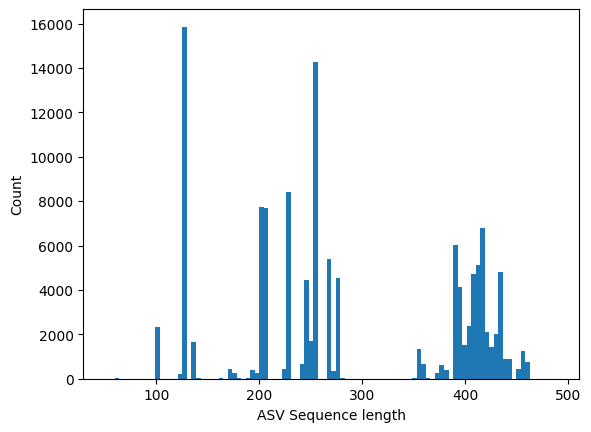

In [14]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print("Max ASV sequence length:", MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Train-test split.

In [15]:
# Split each project separately.
from typing import Tuple
import numpy as np

def train_test_split_per_project(sample_df: pd.DataFrame, seed: int, train_test_ratio: float = 4.0) -> Tuple[pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    train_sections = []
    test_sections = []
    
    train_frac = train_test_ratio / (1 + train_test_ratio)
    test_frac = 1 - train_frac
    
    for proj_id, proj_section in sample_df.groupby("project"):
        # Create shuffled indices
        indices = np.arange(proj_section.shape[0])
        rng.shuffle(indices)

        # split the indices.
        n_train_rows = int(proj_section.shape[0] * train_frac)
        train_indices = indices[:n_train_rows]
        test_indices = indices[n_train_rows:]

        # gather the rows.
        train_df = proj_section.iloc[train_indices].reset_index(drop=True)
        test_df = proj_section.iloc[test_indices].reset_index(drop=True)
        train_sections.append(train_df)
        test_sections.append(test_df)

    train = pd.concat(train_sections, ignore_index=True, axis=0)
    test = pd.concat(test_sections, ignore_index=True, axis=0)
    return train, test


def greedy_project_partition(sample_df: pd.DataFrame, train_test_ratio: float = 4.0) -> Tuple[pd.DataFrame, pd.DataFrame]:
    train_sections = []
    test_sections = []
    
    train_frac = train_test_ratio / (1 + train_test_ratio)
    train_quota = int(train_frac * sample_df.shape[0])
    test_quota = sample_df.shape[0] - train_quota

    train_proj_ids = []
    test_proj_ids = []
    for (proj_id, n_samples) in sample_subset.groupby('project')['srs'].count().sort_values(ascending=False).items():
        if train_quota > 0:
            train_proj_ids.append(proj_id)
            train_quota -= n_samples
        else:
            test_proj_ids.append(proj_id)

    print("TRAIN")
    # display(pd.unique(sample_subset.loc[sample_subset['project'].isin(set(train_proj_ids)), 'geo_loc_name']))
    display(sample_subset.loc[sample_subset['project'].isin(set(train_proj_ids))])
    print("TEST")
    # display(pd.unique(sample_subset.loc[sample_subset['project'].isin(set(test_proj_ids)), 'geo_loc_name']))
    display(sample_subset.loc[sample_subset['project'].isin(set(test_proj_ids))])
    
    train = sample_df.loc[sample_df['project'].isin(set(train_proj_ids))]
    test = sample_df.loc[sample_df['project'].isin(set(test_proj_ids))]
    return train, test


def project_cross_validation(sample_df: pd.DataFrame) -> Iterator[Tuple[pd.DataFrame, pd.DataFrame]]:
    for proj_id in set(sample_df['project']):
        train_df = sample_df.loc[sample_df['project'] != proj_id]
        test_df = sample_df.loc[sample_df['project'] == proj_id]
        yield proj_id, train_df, test_df


def restrict_samples_to_proj(parent_df_dir: Path, project_ids: Set[str]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    parent_train_path = parent_df_dir / "train.tsv"
    parent_test_path = parent_df_dir / "test.tsv"
    train_df = pd.read_csv(parent_train_path, sep='\t')
    test_df = pd.read_csv(parent_test_path, sep='\t')

    train_df = train_df.loc[train_df['project'].isin(project_ids)]
    test_df = test_df.loc[test_df['project'].isin(project_ids)]
    return train_df, test_df

In [16]:
ANALYSIS_DIR = NOTEBOOK_CACHE / "analyses"
ANALYSIS_DIR.mkdir(exist_ok=True)


analysis_names = []
""" ============== split 1: random test-train split, where each project is divided in a specific ratio. test/train each gets a fraction of each project. ============== """
analysis_name = "random_split"
analysis_dir = ANALYSIS_DIR / analysis_name
analysis_dir.mkdir(exist_ok=True)

train_df, test_df = train_test_split_per_project(sample_df=sample_subset, seed=314159)
train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
analysis_names.append(analysis_name)


# """ ============== split 2: greedy train-test split, where entire projects are assigned to test, or train. Zero project overlap between test/train. ============== """
# analysis_name = "project_split"
# analysis_dir = ANALYSIS_DIR / analysis_name
# analysis_dir.mkdir(exist_ok=True)

# train_df, test_df = greedy_project_partition(sample_df=sample_subset)
# train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
# test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
# analysis_names.append(analysis_name)


# """ ============== extra: cross-validation for held-out projects. ============== """
# for proj_id, train_df, test_df in project_cross_validation(sample_subset):
#     analysis_name = f"LOO_{proj_id}"
#     analysis_dir = ANALYSIS_DIR / analysis_name
#     analysis_dir.mkdir(exist_ok=True)
#     train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
#     test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
#     analysis_names.append(analysis_name)


""" 
============== extra: data ablation: v3v4-only training vs all-training ==============
Question: For predicting v3v4 amplicon abundances, does training on v3 and v4 amplicons help, 
in addition to v3-v4 amplicons? Compare training on 'everything' vs 'v3v4'.
"""
analysis_name = "data_ablation_v3v4"
analysis_dir = ANALYSIS_DIR / analysis_name
analysis_dir.mkdir(exist_ok=True)

train_df, test_df = restrict_samples_to_proj(
    ANALYSIS_DIR / "random_split",
    {"PRJNA726866", "PRJNA622517", "PRJNA540406", "PRJNA625181", "PRJNA642894", "PRJEB33905", "PRJEB31155", "PRJNA600229", "PRJNA644097"}
)
train_df.to_csv(analysis_dir / "train.tsv", sep="\t", index=False)
test_df.to_csv(analysis_dir / "test.tsv", sep="\t", index=False)
analysis_names.append(analysis_name)

In [17]:
# sanity check: make sure samples don't overlap.
# Reload from the saved file, just as an extra layer of sanity check.
for analysis_name in analysis_names: 
    analysis_dir = ANALYSIS_DIR / analysis_name
    print(f"Analysis subdir: {analysis_dir}")
    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")
    
    print("Total samples: {}".format(sample_subset.shape[0]))
    print("# train samples: {}".format(train_df.shape[0]))
    print("# test samples: {}".format(test_df.shape[0]))
    print("Ratio: {} / {} = {}".format(
        train_df.shape[0], test_df.shape[0], train_df.shape[0] / test_df.shape[0]
    ))
    
    assert len(set(train_df['srs']).intersection(set(test_df['srs']))) == 0, "Train and test share samples! (this should never happen)"

Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/random_split
Total samples: 12074
# train samples: 9640
# test samples: 2434
Ratio: 9640 / 2434 = 3.960558751027116
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/data_ablation_v3v4
Total samples: 12074
# train samples: 1262
# test samples: 319
Ratio: 1262 / 319 = 3.956112852664577


# Create TRAIN and TEST ASV subset ID files.

This is for the pre-computation of the test vs. train ASV nearest-neighbor calculations (downstream analysis, enabling nearest-neighbor baseline methods)

## Step 1 -- create the train/test ASV id files.

In [20]:
from common.preprocess import dump_asv_ids

def generate_nn_lookup_command(out_dir: Path, train_df: pd.DataFrame, test_df: pd.DataFrame, abundance_table_dir: Path, asv_seqs_subset: Dict[str, str], name: str) -> str:
    train_in = out_dir / f"asv_ids.train.{name}.txt"
    test_in = out_dir / f"asv_ids.test.{name}.txt"
    out_path = out_dir / f"precomputed.{name}.tsv"
    
    dump_asv_ids(asv_seqs_subset, train_df, abundance_table_dir, train_in)
    dump_asv_ids(asv_seqs_subset, test_df, abundance_table_dir, test_in)
    command = f'aligned_nearest_neighbor -i "{asv_align_file}" -o "{out_path.name}" -n {n_suggested_workers} -q "{test_in.name}" -d "{train_in.name}"'
    return command


n_suggested_workers = 20
for analysis_name in analysis_names:
    analysis_dir = ANALYSIS_DIR / analysis_name
    train_df = pd.read_csv(analysis_dir / "train.tsv", sep="\t")
    test_df = pd.read_csv(analysis_dir / "test.tsv", sep="\t")
    
    nn_lookup_dir = analysis_dir / 'nearest_neighbors'
    print(f"********* {analysis_name} **********")
    print(f"Analysis subdir: {analysis_dir}")
    print("Initializing train/test nearest-neighbor precalculation in: {}".format(nn_lookup_dir))
    suggested_commands = []

    # dump entire set
    suggested_commands.append(
        generate_nn_lookup_command(nn_lookup_dir, train_df, test_df, abundance_table_dir, asv_seqs_subset, name="all")
    )

    # dump by project
    for proj_id, test_proj_section in test_df.groupby("project"):
        train_proj_section = train_df.loc[train_df['project'] == proj_id]
        if train_proj_section.shape[0] == 0:
            print(f"Project {proj_id} was in test set, but not in train set. Skipping paired nearest-neighbor query builder!")
        else:
            suggested_commands.append(
                generate_nn_lookup_command(nn_lookup_dir, train_proj_section, test_proj_section, abundance_table_dir, asv_seqs_subset, name=proj_id)
            )

    print("Run these commands to pre-calculate all nearest neighbor queries:")
    print("\n\n")
    print(f"cd {nn_lookup_dir}")
    for cmd in suggested_commands:
        print(f"{cmd}")

********* random_split **********
Analysis subdir: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/random_split
Initializing train/test nearest-neighbor precalculation in: /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/random_split/nearest_neighbors
Run these commands to pre-calculate all nearest neighbor queries:



cd /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/random_split/nearest_neighbors
aligned_nearest_neighbor -i "/data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_alignment.fasta" -o "precomputed.all.tsv" -n 20 -q "asv_ids.test.all.txt" -d "asv_ids.train.all.txt"
aligned_nearest_neighbor -i "/data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_alignment.fasta" -o "precomputed.PRJDB10527.tsv" -n 20 -q "asv_ids.test.PRJDB105

## Next instructions:

In [29]:
for analysis_name in analysis_names:
    analysis_dir = ANALYSIS_DIR / analysis_name
    print(f"********* {analysis_name} **********")
    n_workers = 20
    command = f'aligned_nearest_neighbor -i "{asv_align_file}" -o precomputed.tsv -n {n_workers} -q test_asv_ids.txt -d train_asv_ids.txt -l {ASV_PROJECT_SRC_METADATA}'

    print("Run these commands to pre-calculate all nearest neighbor queries:")
    print()
    print(f"> cd {analysis_dir / 'nearest_neighbors'}")
    print(f"> {command}")

********* random_split **********
Run these commands to pre-calculate all nearest neighbor queries:

> cd /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/random_split/nearest_neighbors
> aligned_nearest_neighbor -i "/data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_alignment.fasta" -o precomputed.tsv -n 20 -q test_asv_ids.txt -d train_asv_ids.txt -l /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_project_ids.tsv
********* data_ablation_v3v4 **********
Run these commands to pre-calculate all nearest neighbor queries:

> cd /data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/analyses/data_ablation_v3v4/nearest_neighbors
> aligned_nearest_neighbor -i "/data/bwh-comppath-seq/youn/human_microbiome_compendium/v3v4_split_multiproj_extended/asv_16s_processing/asv_alignment.fasta" -o precomputed.t

# Old code below (unused)

In [119]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
4,PRJDB10527,https://doi.org/10.1186/s12866-021-02215-0,v3-v4,274.78,True,Gene Prep Star PI-480 device (Kurabo Industries),stool,healthy,adults,NaN
5,PRJDB10612,https://doi.org/10.1016/j.foodres.2021.110326,v3-v4,254.00,True,Gene Prep Star PI-480,stool,healthy,adults,"Beads used, but for purification"
38,PRJNA625181,https://doi.org/10.1038/s43587-021-00129-0,v3-v4,420.40,True,TIANamp Stool DNA Kit,stool,healthy,adults,NaN
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
50,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN
56,PRJEB40569,https://doi.org/10.3389/fcimb.2022.722886,v3-v4,380.96,True,NucleoSpin DNA Stool kit,stool,healthy,adults,NaN
60,PRJEB35769,https://doi.org/10.1038/s41598-020-72161-w,v3-v4,385.52,True,custom,stool,healthy,adults,"mechanical lysis (FastprepFP120; ThermoSavant,..."
64,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
70,PRJEB33905,https://doi.org/10.1128/mSystems.00179-21,v3-v4,401.41,False,"QIAamp DNA stool minikit (Qiagen, Hilden, Germ...",stool,healthy,adults,NaN


In [26]:
# # from common.util import ASVDistanceMatrixSparse

# # distmat_file = asv_align_file.parent / "distance_matrix.npz"
# # if distmat_file.exists():
# #     dist_mat = ASVDistanceMatrixSparse.load(distmat_file)
# # else:
# #     dist_mat = ASVDistanceMatrixSparse.from_alignment_sparse(asv_align_file, n_threads=20)
# #     dist_mat.save(asv_align_file.parent / "distance_matrix.npz")
# distmat_variable_name = 'dist_mat'
# if distmat_variable_name in locals() or distmat_variable_name in globals():
#     print(f"'{distmat_variable_name}' exists.")
#     dist_mat.shutdown()
#     del dist_mat

In [40]:
# from common.util import ASVDistanceMatrixLazy
# dist_mat = ASVDistanceMatrixLazy(asv_align_file, n_workers=20)


# train_df, test_df = train_test_split_mincut_approximation(
#     sample_df=sample_subset, 
#     abundance_table_dir=abundance_table_dir,
#     asv_id_subset=set(asv_seqs_subset.keys()), 
#     train_fraction=0.8, 
#     test_fraction=0.2,
#     distance_matrix=dist_mat,
# )
# train_df.to_csv(NOTEBOOK_CACHE / "train.tsv", sep="\t", index=False)
# test_df.to_csv(NOTEBOOK_CACHE / "test.tsv", sep="\t", index=False)
    
# print("# train samples: {}".format(train_df.shape[0]))
# print("# test samples: {}".format(test_df.shape[0]))
# print("Ratio: {} / {} = {}".format(
#     train_df.shape[0], test_df.shape[0], train_df.shape[0] / test_df.shape[0]
# ))

# dist_mat.shutdown()

In [49]:
sample_subset.groupby('region')['srs'].count()

region
Australia/New Zealand                 78
Central and Southern Asia              5
Eastern and South-Eastern Asia       345
Europe and Northern America         8454
Latin America and the Caribbean        1
Northern Africa and Western Asia       4
Oceania                                4
Sub-Saharan Africa                   542
unknown                             2641
Name: srs, dtype: int64

In [37]:
train_df.groupby("project")['srs'].count().to_frame()

,srs
project,
PRJDB10527,39
PRJDB10612,67
PRJEB11419,3078
PRJEB23775,86
PRJEB31155,1
PRJEB32537,16
PRJEB33065,19
PRJEB33905,489
PRJEB35769,169


In [38]:
test_df.groupby("project")['srs'].count().to_frame()

,srs
project,
PRJDB10527,10
PRJDB10612,17
PRJEB11419,770
PRJEB23775,22
PRJEB31155,1
PRJEB32537,4
PRJEB33065,5
PRJEB33905,123
PRJEB35769,43


In [39]:
project_subset

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
4,PRJDB10527,https://doi.org/10.1186/s12866-021-02215-0,v3-v4,274.78,True,Gene Prep Star PI-480 device (Kurabo Industries),stool,healthy,adults,NaN
5,PRJDB10612,https://doi.org/10.1016/j.foodres.2021.110326,v3-v4,254.00,True,Gene Prep Star PI-480,stool,healthy,adults,"Beads used, but for purification"
38,PRJNA625181,https://doi.org/10.1038/s43587-021-00129-0,v3-v4,420.40,True,TIANamp Stool DNA Kit,stool,healthy,adults,NaN
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
50,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN
56,PRJEB40569,https://doi.org/10.3389/fcimb.2022.722886,v3-v4,380.96,True,NucleoSpin DNA Stool kit,stool,healthy,adults,NaN
60,PRJEB35769,https://doi.org/10.1038/s41598-020-72161-w,v3-v4,385.52,True,custom,stool,healthy,adults,"mechanical lysis (FastprepFP120; ThermoSavant,..."
64,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN
70,PRJEB33905,https://doi.org/10.1128/mSystems.00179-21,v3-v4,401.41,False,"QIAamp DNA stool minikit (Qiagen, Hilden, Germ...",stool,healthy,adults,NaN
